# Проект модуля (HW-03)

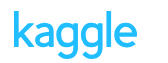

# О датасете и кейсе с Kaggle:

### Corporación Favorita Grocery Sales Forecasting

### Dataset Description

In this competition, you will be predicting the unit sales for thousands of items sold at different Favorita stores located in Ecuador. The training data includes dates, store and item information, whether that item was being promoted, as well as the unit sales. Additional files include supplementary information that may be useful in building your models.

### File Descriptions and Data Field Information

**train.csv**

- Training data, which includes the target unit_sales by date, store_nbr, and item_nbr and a unique id to label rows.
- The target unit_sales can be integer (e.g., a bag of chips) or float (e.g., 1.5 kg of cheese).
- Negative values of unit_sales represent returns of that particular item.
- The onpromotion column tells whether that item_nbr was on promotion for a specified date and store_nbr.
- Approximately 16% of the onpromotion values in this file are NaN.

NOTE: The training data does not include rows for items that had zero unit_sales for a store/date combination. There is no information as to whether or not the item was in stock for the store on the date, and teams will need to decide the best way to handle that situation. Also, there are a small number of items seen in the training data that aren't seen in the test data.

**test.csv**

- Test data, with the date, store_nbr, item_nbr combinations that are to be predicted, along with the onpromotion information.
- NOTE: The test data has a small number of items that are not contained in the training data. Part of the exercise will be to predict a new item sales based on similar products..
- The public / private leaderboard split is based on time. All items in the public split are also included in the private split.

**sample_submission.csv**

- A sample submission file in the correct format.
- It is highly recommend you zip your submission file before uploading!

**stores.csv**

- Store metadata, including city, state, type, and cluster.
- cluster is a grouping of similar stores.

**items.csv**

- Item metadata, including family, class, and perishable.
- NOTE: Items marked as perishable have a score weight of 1.25; otherwise, the weight is 1.0.

**transactions.csv**

- The count of sales transactions for each date, store_nbr combination. Only included for the training data timeframe.

**oil.csv**

- Daily oil price. Includes values during both the train and test data timeframe. (Ecuador is an oil-dependent country and it's economical health is highly vulnerable to shocks in oil prices.)
holidays_events.csv

- Holidays and Events, with metadata
- NOTE: Pay special attention to the transferred column. A holiday that is transferred officially falls on that calendar day, but was moved to another date by the government. A transferred day is more like a normal day than a holiday. To find the day that it was actually celebrated, look for the corresponding row where type is Transfer. For example, the holiday Independencia de Guayaquil was transferred from 2012-10-09 to 2012-10-12, which means it was celebrated on 2012-10-12. Days that are type Bridge are extra days that are added to a holiday (e.g., to extend the break across a long weekend). These are frequently made up by the type Work Day which is a day not normally scheduled for work (e.g., Saturday) that is meant to payback the Bridge.
- Additional holidays are days added a regular calendar holiday, for example, as typically happens around Christmas (making Christmas Eve a holiday).

### Additional Notes
- Wages in the public sector are paid every two weeks on the 15 th and on the last day of the month. Supermarket sales could be affected by this.
- A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake.

> # <center> PDA-2. Обработка временных рядов

### Импортируем библиотеки:

In [192]:
import pandas as pd
import numpy as np

from matplotlib import pyplot
import matplotlib.pyplot as plt 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

from prophet import Prophet
import holidays as holidays_lib

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# 5. Характеристики и параметры временных рядов. Практика

Загрузим данные:

In [193]:
data = pd.read_csv('train/train.csv') # считываем датасет
data.head(3) # смотрим на первые несколько строчек

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN


Сгруппируeм данные по дате и суммируем количество всех продаж.

In [194]:
df = data[data.store_nbr==25].groupby("date")['unit_sales'].sum().reset_index()
df.head(3)

,date,unit_sales
0,2013-01-01,2511.619
1,2013-01-02,5316.224
2,2013-01-03,4442.913


Приводим индексы к стандарту pd.Datetime, чтобы потом это можно было скормить seasonal_decompose

In [195]:
df = df.set_index(pd.DatetimeIndex(df['date'])) 
df.drop(['date'], axis = 1, inplace = True)
df.head(3)

,unit_sales
date,
2013-01-01,2511.619
2013-01-02,5316.224
2013-01-03,4442.913


Применяем seasonal_decompose

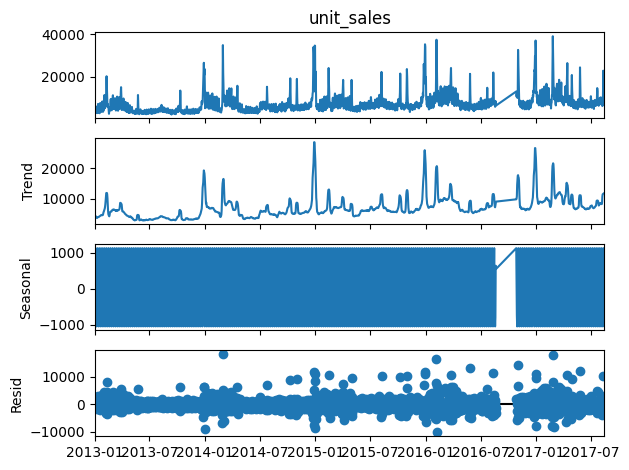

In [196]:
# эта функция разложит ряд на трендовую, сезонную и шумовую составляющие
# задаем период явно (для дневных данных берем недельную сезонность)
decomposition = seasonal_decompose(df['unit_sales'], model='additive', period=7)
decomposition.plot()
pyplot.show() # любуемся результатом

### Задание:

В Jupyter Notebook ответьте на вопросы:

1. Сколько элементов содержит исходный датасет?

2. Сколько элементов содержит шумовая часть?

3. Сколько числовых элементов содержит шумовая часть?

4. Сколько элементов содержит сезонная часть?

5. Сколько числовых элементов содержит трендовая часть?

6. Выполните тест Дики-Фуллера.

1-5. Ответы

In [197]:
# Исходный ряд, который разлагали
original_series = df['unit_sales']

# Компоненты разложения
resid = decomposition.resid
seasonal = decomposition.seasonal
trend = decomposition.trend

# Ответы на вопросы 1-5
print(f"1. Количество элементов в исходном датасете: {len(original_series)}")
print(f"2. Количество элементов в шумовой части: {len(resid)}")
print(f"3. Количество числовых элементов в шумовой части: {resid.notna().sum()}")
print(f"4. Количество элементов в сезонной части: {len(seasonal)}")
print(f"5. Количество числовых элементов в трендовой части: {trend.notna().sum()}")

1. Количество элементов в исходном датасете: 1618
2. Количество элементов в шумовой части: 1618
3. Количество числовых элементов в шумовой части: 1612
4. Количество элементов в сезонной части: 1618
5. Количество числовых элементов в трендовой части: 1612


6. Тест Дики-Фуллера

In [198]:
adf_result = adfuller(original_series.dropna())

print("\n Тест Дики-Фуллера:")
print(f"ADF-статистика: {adf_result[0]:.6f}")
print(f"p-value: {adf_result[1]:.6f}")
print(f"Количество лагов: {adf_result[2]}")
print(f"Количество наблюдений: {adf_result[3]}")
print("Критические значения:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.6f}")

if adf_result[1] < 0.05:
    print("Вывод: ряд стационарен (отвергаем H0 о не стационарности).")
else:
    print("Вывод: ряд нестационарен (нет оснований отвергнуть H0).")


 Тест Дики-Фуллера:
ADF-статистика: -4.858993
p-value: 0.000042
Количество лагов: 25
Количество наблюдений: 1592
Критические значения:
  1%: -3.434464
  5%: -2.863357
  10%: -2.567737
Вывод: ряд стационарен (отвергаем H0 о не стационарности).


# 6. Особенности валидации временных рядов

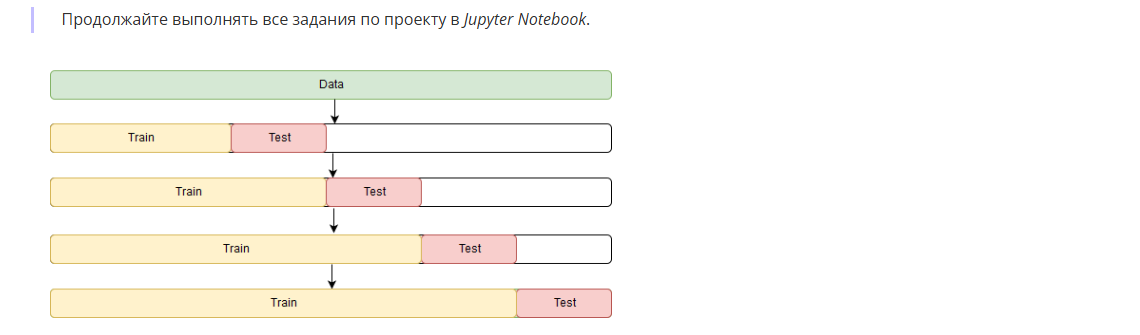

1. Разбейте временной ряд, полученный в предыдущем юните, на три (train + test) набора. Для этого воспользуйтесь TimeSeriesSplit из sklearn.model_selection с параметром n_splits=3 и test_size=7. Наборы данных можно получить, вызвав метод split (временной ряд) у инициализированного TimeSeriesSplit.

2. Выведите размеры полученных подвыборок.

Ответ:

In [199]:
# Берем временной ряд продаж
series = df['unit_sales']

# Разбиение на 3 фолда с тестовым окном 7 наблюдений
tscv = TimeSeriesSplit(n_splits=3, test_size=7)
train_test_groups = tscv.split(series)

for i, (train_index, test_index) in enumerate(train_test_groups, start=1):
    print(f"Split {i}: TRAIN size = {len(train_index)}, TEST size = {len(test_index)}")

Split 1: TRAIN size = 1597, TEST size = 7
Split 2: TRAIN size = 1604, TEST size = 7
Split 3: TRAIN size = 1611, TEST size = 7


# 8. Расчёт факторов при помощи pandas. Практика

### Задание:

1. Выберите временной ряд для одного магазина (можно использовать из прошлого задания).

2. Постройте скользящее среднее c окном 5.

3. Постройте скользящее квадратическое отклонение c окном 5. 

4. Постройте так называемые линии Боллинджера с окном в 30 (если этого позволяет выбранный ряд): добавьте к скользящему среднему скользящее стандартное отклонение, умноженное на три — верхняя линия Боллинджера; отнимите от скользящего среднего скользящее стандартное отклонение, умноженное на три — нижняя линия Боллинджера.

> upper = rolling_mean + 3 * rolling_std
> 
> lower = rolling_mean - 3 * rolling_std

5. Отобразите эти оконные факторы на графике. 

6. Постройте оконное среднее с окном в 10 точек.

7. Постройте экспоненциально среднее с окном в 7 точек (span=7).

8. Отобразите их на отдельном графике. 

9. Напишите свою скользящую функцию, которая будет являться средним арифметическим между максимальным и минимальным значением unit_sales, используя окно 10.

10. Постройте скользящее среднее с окном 50 и экспоненциальное скользящее среднее с окном 10 (span=10). Укажите индексы датафрейма, на которых одно скользящее пересекается с другим. Для этого вычтите из одно скользящего среднего другое, возьмите знак этой разности (np.sign), продифференциируйте его (diff()) и оставьте только те точки, где результат дифференциирования не равен нулю.

11. Получите лаговые факторы с 7-го по 10-й предыдущих дня (лаг7, лаг8, лаг9, лаг10) и отобразите на графике. 

1. Используем ряд продаж для магазина 25 из предыдущих шагов

In [200]:
series = df['unit_sales'].copy()

2-4. Скользящее среднее/стандартное отклонение (окно 5) и линии Боллинджера (окно 30)

In [201]:
df['rolling_mean_5'] = series.rolling(window=5).mean()
df['rolling_std_5'] = series.rolling(window=5).std()

df['bb_mean_30'] = series.rolling(window=30).mean()
df['bb_std_30'] = series.rolling(window=30).std()
df['bb_upper_30'] = df['bb_mean_30'] + 3 * df['bb_std_30']
df['bb_lower_30'] = df['bb_mean_30'] - 3 * df['bb_std_30']

5. График оконных факторов и линий Боллинджера

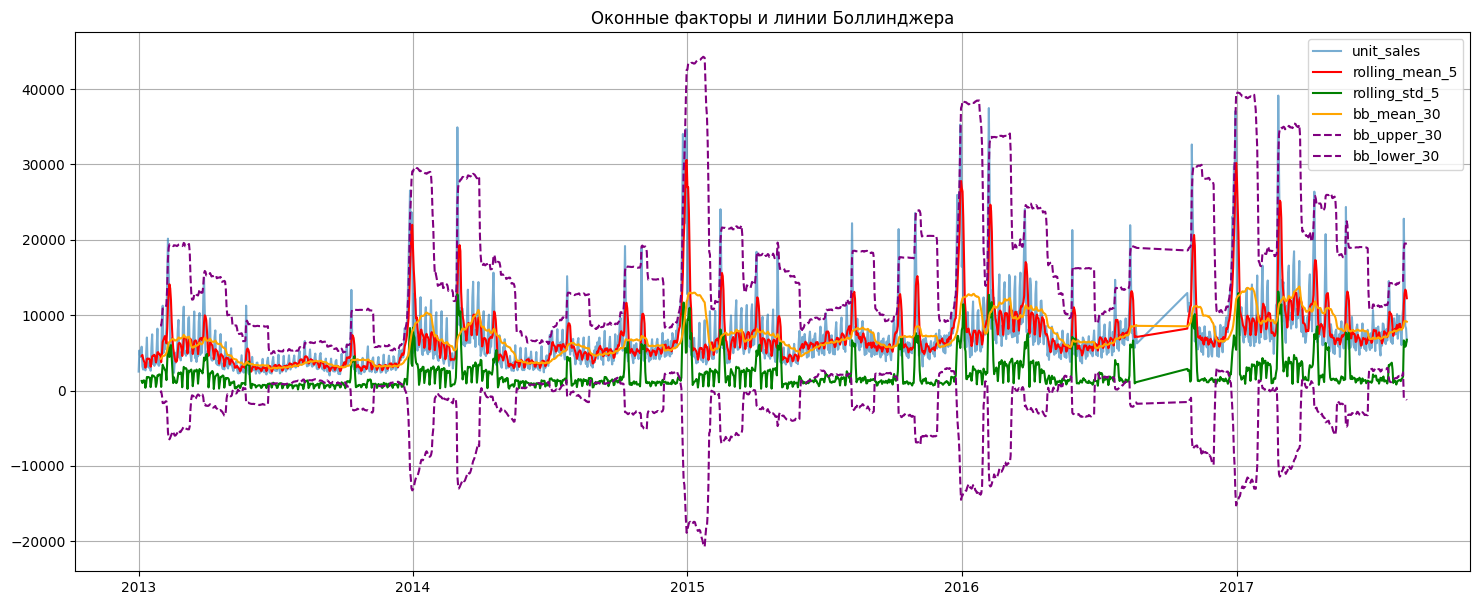

In [202]:
plt.figure(figsize=(18, 7))
plt.plot(df.index, series, label='unit_sales', alpha=0.6)
plt.plot(df.index, df['rolling_mean_5'], label='rolling_mean_5', color='red')
plt.plot(df.index, df['rolling_std_5'], label='rolling_std_5', color='green')
plt.plot(df.index, df['bb_mean_30'], label='bb_mean_30', color='orange')
plt.plot(df.index, df['bb_upper_30'], label='bb_upper_30', color='purple', linestyle='--')
plt.plot(df.index, df['bb_lower_30'], label='bb_lower_30', color='purple', linestyle='--')
plt.title('Оконные факторы и линии Боллинджера')
plt.legend()
plt.grid(True)
plt.show()

6-7. SMA(10) и EMA(span=7)

In [203]:
df['sma_10'] = series.rolling(window=10).mean()
df['ema_7'] = series.ewm(span=7, adjust=False).mean()

8. Отдельный график для SMA(10) и EMA(7)

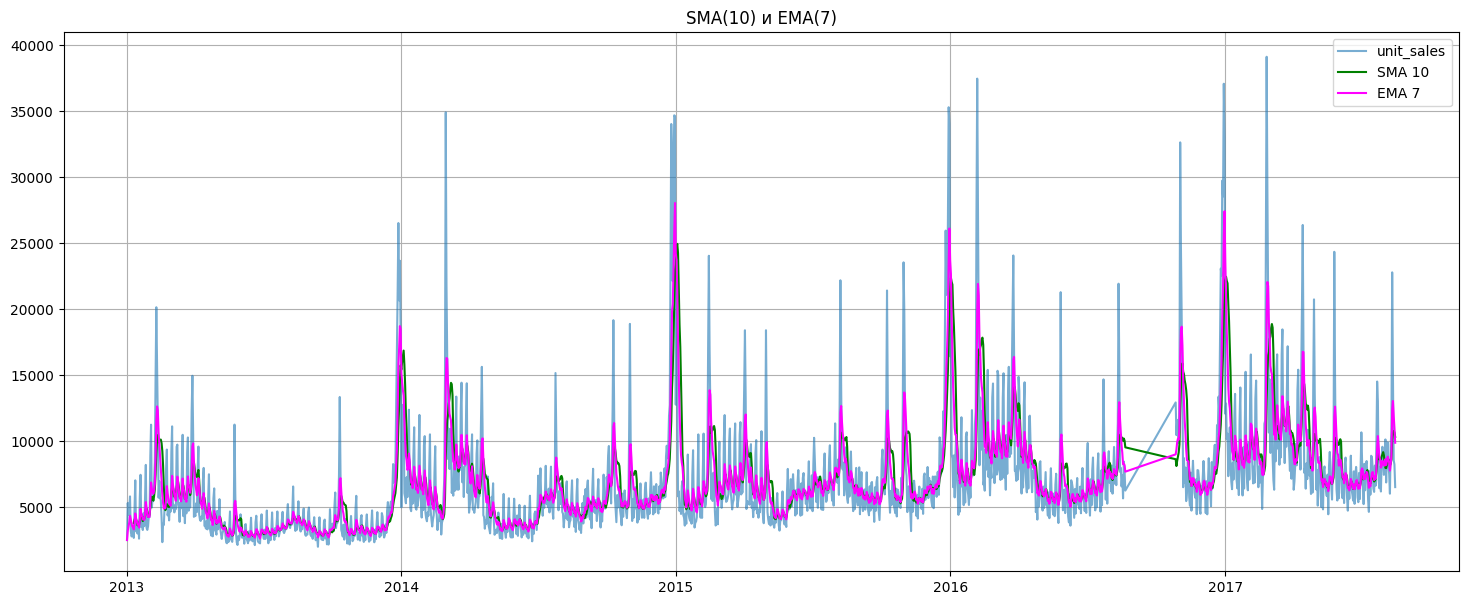

In [204]:
plt.figure(figsize=(18, 7))
plt.plot(df.index, series, label='unit_sales', alpha=0.6)
plt.plot(df.index, df['sma_10'], label='SMA 10', color='green')
plt.plot(df.index, df['ema_7'], label='EMA 7', color='magenta')
plt.title('SMA(10) и EMA(7)')
plt.legend()
plt.grid(True)
plt.show()

9. Своя скользящая функция: среднее между max и min в окне 10

In [205]:
def avg_max_min(values):
    return (values.max() + values.min()) / 2

df['rolling_avg_max_min_10'] = series.rolling(window=10).apply(avg_max_min, raw=False)

10. SMA(50) и EMA(10), индексы пересечений

In [206]:
df['sma_50'] = series.rolling(window=50).mean()
df['ema_10'] = series.ewm(span=10, adjust=False).mean()

# Убираем NaN (период разогрева окон), затем ищем смену знака
valid = df[['sma_50', 'ema_10']].dropna()
sign_diff = np.sign(valid['sma_50'] - valid['ema_10']).diff()
cross_idx = sign_diff[sign_diff != 0].index

print('Индексы пересечений SMA(50) и EMA(10):')
print(cross_idx)

Индексы пересечений SMA(50) и EMA(10):
DatetimeIndex(['2013-02-19', '2013-02-20', '2013-02-22', '2013-02-26',
               '2013-03-02', '2013-03-05', '2013-03-09', '2013-03-11',
               '2013-03-16', '2013-03-17',
               ...
               '2017-04-19', '2017-04-29', '2017-05-02', '2017-05-26',
               '2017-05-30', '2017-06-03', '2017-06-05', '2017-07-02',
               '2017-07-04', '2017-07-15'],
              dtype='datetime64[ns]', name='date', length=129, freq=None)


11. Лаговые факторы 7-10 и их визуализация

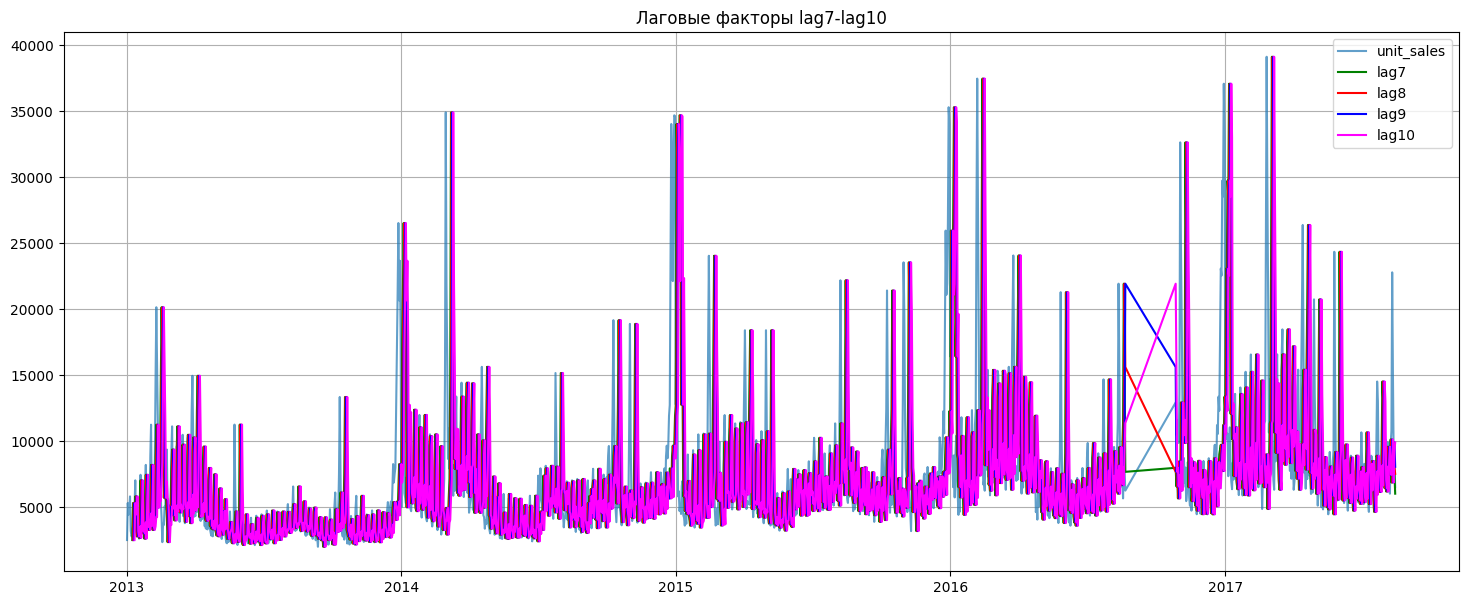

,unit_sales,rolling_mean_5,rolling_std_5,bb_upper_30,bb_lower_30,sma_10,ema_7,rolling_avg_max_min_10,sma_50,ema_10,lag7,lag8,lag9,lag10
date,,,,,,,,,,,,,,
2013-01-01,2511.619,NaN,NaN,NaN,NaN,NaN,2511.619000,NaN,NaN,2511.619000,NaN,NaN,NaN,NaN
2013-01-02,5316.224,NaN,NaN,NaN,NaN,NaN,3212.770250,NaN,NaN,3021.547182,NaN,NaN,NaN,NaN
2013-01-03,4442.913,NaN,NaN,NaN,NaN,NaN,3520.305938,NaN,NaN,3279.977331,NaN,NaN,NaN,NaN
2013-01-04,4844.354,NaN,NaN,NaN,NaN,NaN,3851.317953,NaN,NaN,3564.409452,NaN,NaN,NaN,NaN
2013-01-05,5817.526,4586.5272,1268.873437,NaN,NaN,NaN,4342.869965,NaN,NaN,3974.067006,NaN,NaN,NaN,NaN
2013-01-06,3201.695,4724.5424,994.665070,NaN,NaN,NaN,4057.576224,NaN,NaN,3833.635733,NaN,NaN,NaN,NaN
2013-01-07,2783.978,4218.0932,1233.965510,NaN,NaN,NaN,3739.176668,NaN,NaN,3642.788872,NaN,NaN,NaN,NaN
2013-01-08,2884.284,3906.3674,1354.005326,NaN,NaN,NaN,3525.453501,NaN,NaN,3504.878895,2511.619,NaN,NaN,NaN
2013-01-09,3565.639,3650.6244,1249.257405,NaN,NaN,NaN,3535.499876,NaN,NaN,3515.926187,5316.224,2511.619,NaN,NaN


In [207]:
for lag in range(7, 11):
    df[f'lag{lag}'] = series.shift(lag)

plt.figure(figsize=(18, 7))
plt.plot(df.index, series, label='unit_sales', alpha=0.7)
for lag, color in zip(range(7, 11), ['green', 'red', 'blue', 'magenta']):
    plt.plot(df.index, df[f'lag{lag}'], label=f'lag{lag}', color=color)
plt.title('Лаговые факторы lag7-lag10')
plt.legend()
plt.grid(True)
plt.show()

# Превью рассчитанных признаков
df[['unit_sales', 'rolling_mean_5', 'rolling_std_5', 'bb_upper_30', 'bb_lower_30',
    'sma_10', 'ema_7', 'rolling_avg_max_min_10', 'sma_50', 'ema_10',
    'lag7', 'lag8', 'lag9', 'lag10']].head(15)

# 10. ARIMA/SARIMA. Практика

### Задание:

1. Выберите продукт с номером 103501 (item_nbr) и приведите данные к виду временного ряда с группировкой по дате и агрегацией .sum()['unit_sales']. 

2. Проведите тест Адфуллера. Стационарен ли ряд?

3. Постройте прогноз методом скользящего среднего с окном 6, как в ноутбуке выше. Посчитайте метрики MSE, MAE, MAPE.

4. Сделайте лаги с 1 по 6. 

    Обратите внимание: если на реальных данных вам нужно будет предсказывать, например, на 100 дней вперёд, вы не сможете взять лаги с 1 по 6, но сможете лишь с 100-го дня. (поскольку для 99 дня нельзя получить лаги с 1 по 99 — эти значения в будущем не известны).

5. Отложите 1-2 последних дня в тестовую выборку для совершения предсказания.

6. Сделайте прогноз линейной регрессией, посчитайте значения метрик MSE, MAE, MAPE. 

7. Определите 'p' и 'q'.

8. Постройте ARIMA, сравните метрики. 

9. Сделайте вывод.

1. Ряд для item_nbr = 103501

In [208]:
# 1) Ряд для item_nbr = 103501
item_id = 103501

ts = (
    data.loc[data['item_nbr'] == item_id]
    .groupby('date')['unit_sales']
    .sum()
    .sort_index()
)
ts.index = pd.to_datetime(ts.index)
ts = ts.asfreq('D', fill_value=0)
ts.name = 'unit_sales'

print(f'Длина ряда item_nbr={item_id}:', len(ts))
print('Первые даты ряда:')
display(ts.head())

Длина ряда item_nbr=103501: 1687
Первые даты ряда:


date
2013-01-02    185.0
2013-01-03    153.0
2013-01-04    155.0
2013-01-05    160.0
2013-01-06    173.0
Freq: D, Name: unit_sales, dtype: float64

2. Тест Адфуллера

In [209]:
# Тест Адфуллера
adf_res = adfuller(ts.dropna())
print('\nADF statistic:', round(adf_res[0], 6))
print('p-value:', round(adf_res[1], 6))
print('lags:', adf_res[2], '| nobs:', adf_res[3])
for k, v in adf_res[4].items():
    print(f'critical {k}: {v:.6f}')

is_stationary = adf_res[1] < 0.05
print('Стационарен ли ряд?:', 'Да' if is_stationary else 'Нет')

# d для ARIMA
# Если ряд нестационарен, берем d=1, иначе d=0
d_order = 0 if is_stationary else 1

# Вспомогательная метрика MAPE
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100



ADF statistic: -3.289659
p-value: 0.015347
lags: 25 | nobs: 1661
critical 1%: -3.434293
critical 5%: -2.863282
critical 10%: -2.567697
Стационарен ли ряд?: Да


3. Moving Average (window=6)

In [210]:
# Moving Average (window=6)
ma_window = 6
ma_pred_full = ts.shift(1).rolling(ma_window).mean()
ma_pred_test = ma_pred_full.loc[test_ts.index]

ma_mse = mean_squared_error(test_ts, ma_pred_test)
ma_mae = mean_absolute_error(test_ts, ma_pred_test)
ma_mape = mape(test_ts, ma_pred_test)

print('\nМетрики Moving Average (window=6):')
print(f'MSE:  {ma_mse:.4f}')
print(f'MAE:  {ma_mae:.4f}')
print(f'MAPE: {ma_mape:.4f}%')



Метрики Moving Average (window=6):
MSE:  30.2222
MAE:  5.3333
MAPE: 5.9764%


4. Лаги с 1 до 6

In [211]:
# Лаги 1..6
lag_df = pd.DataFrame({'y': ts})
for lag in range(1, 7):
    lag_df[f'lag_{lag}'] = lag_df['y'].shift(lag)

5. Тест: Отложим последние 2 дня

In [212]:
# 5 Тест: последние 2 дня
test_size = 2
train_ts = ts.iloc[:-test_size].copy()
test_ts = ts.iloc[-test_size:].copy()

print('\nTrain size:', len(train_ts), '| Test size:', len(test_ts))
print('Test index:')
print(test_ts.index)



Train size: 1685 | Test size: 2
Test index:
DatetimeIndex(['2017-08-14', '2017-08-15'], dtype='datetime64[ns]', name='date', freq='D')


6. Linear Regression на лагах

In [213]:
# Linear Regression на лагах
lag_df = lag_df.dropna().copy()

train_lag = lag_df.iloc[:-test_size]
test_lag = lag_df.iloc[-test_size:]

X_train = train_lag[[f'lag_{i}' for i in range(1, 7)]]
y_train = train_lag['y']
X_test = test_lag[[f'lag_{i}' for i in range(1, 7)]]
y_test = test_lag['y']

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mape = mape(y_test, lr_pred)

print('\nМетрики Linear Regression (lag_1..lag_6):')
print(f'MSE:  {lr_mse:.4f}')
print(f'MAE:  {lr_mae:.4f}')
print(f'MAPE: {lr_mape:.4f}%')


Метрики Linear Regression (lag_1..lag_6):
MSE:  79.1297
MAE:  7.5054
MAPE: 8.4944%


7. Определение p и q (по минимальному AIC)

In [214]:
# Определение p и q (по минимальному AIC)
best_aic = np.inf
best_order = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = ARIMA(train_ts, order=(p, d_order, q))
            fit = model.fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_order = (p, d_order, q)
        except Exception:
            continue

if best_order is None:
    raise RuntimeError('Не удалось подобрать p,q для ARIMA в заданном диапазоне.')

best_p, _, best_q = best_order
print('\nПодбор ARIMA по AIC:')
print('Лучший order:', best_order, '| AIC:', round(best_aic, 4))
print(f'Определенные параметры: p={best_p}, q={best_q}')


Подбор ARIMA по AIC:
Лучший order: (3, 0, 3) | AIC: 15796.6162
Определенные параметры: p=3, q=3


8. ARIMA прогноз и сравнение метрик


Метрики ARIMA:
MSE:  115.8447
MAE:  10.3543
MAPE: 11.6726%

Сравнение метрик:


,MSE,MAE,MAPE_%
MovingAverage_6,30.222222,5.333333,5.976431
LinearRegression_lags1_6,79.129713,7.505420,8.494409
"ARIMA_(3, 0, 3)",115.844672,10.354313,11.672626


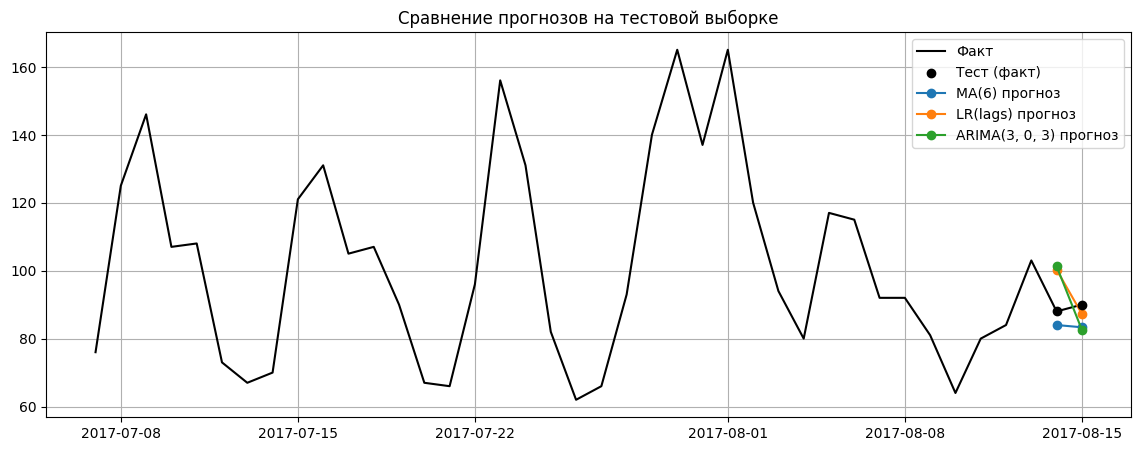

In [215]:
# ARIMA прогноз и сравнение метрик
arima_model = ARIMA(train_ts, order=best_order)
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=test_size)
arima_pred.index = test_ts.index

arima_mse = mean_squared_error(test_ts, arima_pred)
arima_mae = mean_absolute_error(test_ts, arima_pred)
arima_mape = mape(test_ts, arima_pred)

print('\nМетрики ARIMA:')
print(f'MSE:  {arima_mse:.4f}')
print(f'MAE:  {arima_mae:.4f}')
print(f'MAPE: {arima_mape:.4f}%')

# Таблица сравнения
metrics_cmp = pd.DataFrame(
    {
        'MSE': [ma_mse, lr_mse, arima_mse],
        'MAE': [ma_mae, lr_mae, arima_mae],
        'MAPE_%': [ma_mape, lr_mape, arima_mape],
    },
    index=['MovingAverage_6', 'LinearRegression_lags1_6', f'ARIMA_{best_order}']
)

print('\nСравнение метрик:')
display(metrics_cmp)

# График: факт и прогнозы на тесте
plt.figure(figsize=(14, 5))
plt.plot(ts.index[-40:], ts.values[-40:], label='Факт', color='black')
plt.scatter(test_ts.index, test_ts.values, label='Тест (факт)', color='black', zorder=5)
plt.plot(test_ts.index, ma_pred_test.values, label='MA(6) прогноз', marker='o')
plt.plot(test_ts.index, lr_pred, label='LR(lags) прогноз', marker='o')
plt.plot(test_ts.index, arima_pred.values, label=f'ARIMA{best_order} прогноз', marker='o')
plt.title('Сравнение прогнозов на тестовой выборке')
plt.legend()
plt.grid(True)
plt.show()

9. Выводы

In [216]:
# Вывод
best_model_name = metrics_cmp['MAPE_%'].idxmin()
print('Вывод:')
print(
    f"По метрике MAPE лучшая модель: {best_model_name}. "
    f"Ряд {'стационарен' if is_stationary else 'нестационарен'}, "
    f"поэтому для ARIMA использован d={d_order}."
)

# Показать последние строки с лагами 7..10 (иллюстрация из предыдущего пункта модуля)
lag_7_10 = pd.DataFrame({'y': ts})
for lag in range(7, 11):
    lag_7_10[f'lag_{lag}'] = lag_7_10['y'].shift(lag)

print('\nПоследние строки lag_7..lag_10:')
display(lag_7_10.tail(12))

Вывод:
По метрике MAPE лучшая модель: MovingAverage_6. Ряд стационарен, поэтому для ARIMA использован d=0.

Последние строки lag_7..lag_10:


,y,lag_7,lag_8,lag_9,lag_10
date,,,,,
2017-08-04,80.0,93.0,66.0,62.0,82.0
2017-08-05,117.0,140.0,93.0,66.0,62.0
2017-08-06,115.0,165.0,140.0,93.0,66.0
2017-08-07,92.0,137.0,165.0,140.0,93.0
2017-08-08,92.0,165.0,137.0,165.0,140.0
2017-08-09,81.0,120.0,165.0,137.0,165.0
2017-08-10,64.0,94.0,120.0,165.0,137.0
2017-08-11,80.0,80.0,94.0,120.0,165.0
2017-08-12,84.0,117.0,80.0,94.0,120.0


# 12. FPProphet. Практика

### Задание:

1. Приведите данные train.csv к виду временного ряда, сгруппированного по дате, с агрегирующей функцией sum() для столбца unit_sales. У вас должен получиться временной ряд с двумя столбцами: дата и sum_unit_sales. Отобразите на графике. Видно ли влияние сезонности и других факторов на количество покупок?

2. Попробуйте выполнить предсказание пророком (prophet) на год вперёд (periods=365). Отобразите на графике. Посчитайте RSME.

3. Поэкспериментируйте с коэффициентом changepoint_prior_scale (переберите 3-5 значений, больше/меньше 0,5) и посмотрите, как изменится тренд. В какую сторону необходимо двигать коэффициент? Тренд переобучен или недообучен?

4. Отобразите результаты с подобранным коэффициентом на графике. Как изменилась ошибка?

5. Добавьте в модель месячную сезонность (name='monthly', period=30.5, fourier_order=5). Как изменилась ошибка? Улучшилась ли модель? Отобразите на графике. Посчитайте ошибку.

6. Улучшите модель добавлением данных о праздниках. Отобразите результат, сделайте письменный вывод.

> Пометка: в задании не указано работа по всем магазинам или только по store 25. Задание будет выполняться по store 25 как и в предыдущих заданиях.

In [217]:
# для магазина 25 используем уже готовый ряд продаж
prophet_df = df.reset_index().rename(columns={'date': 'ds', 'unit_sales': 'y'})[['ds', 'y']].copy()
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df['y'] = prophet_df['y'].astype(float)

print('Данные для Prophet:')
display(prophet_df.head())

# Вспомогательная функция для расчета RMSE по совпадению дат

def history_rmse(forecast_df, actual_df):
    merged = actual_df.merge(forecast_df[['ds', 'yhat']], on='ds', how='left')
    return np.sqrt(mean_squared_error(merged['y'], merged['yhat']))


Данные для Prophet:


,ds,y
0,2013-01-01,2511.619
1,2013-01-02,5316.224
2,2013-01-03,4442.913
3,2013-01-04,4844.354
4,2013-01-05,5817.526


2. Базовый прогноз Prophet на 365 дней вперед

16:28:33 - cmdstanpy - INFO - Chain [1] start processing
16:28:34 - cmdstanpy - INFO - Chain [1] done processing


RMSE базовой модели Prophet: 3283.4486


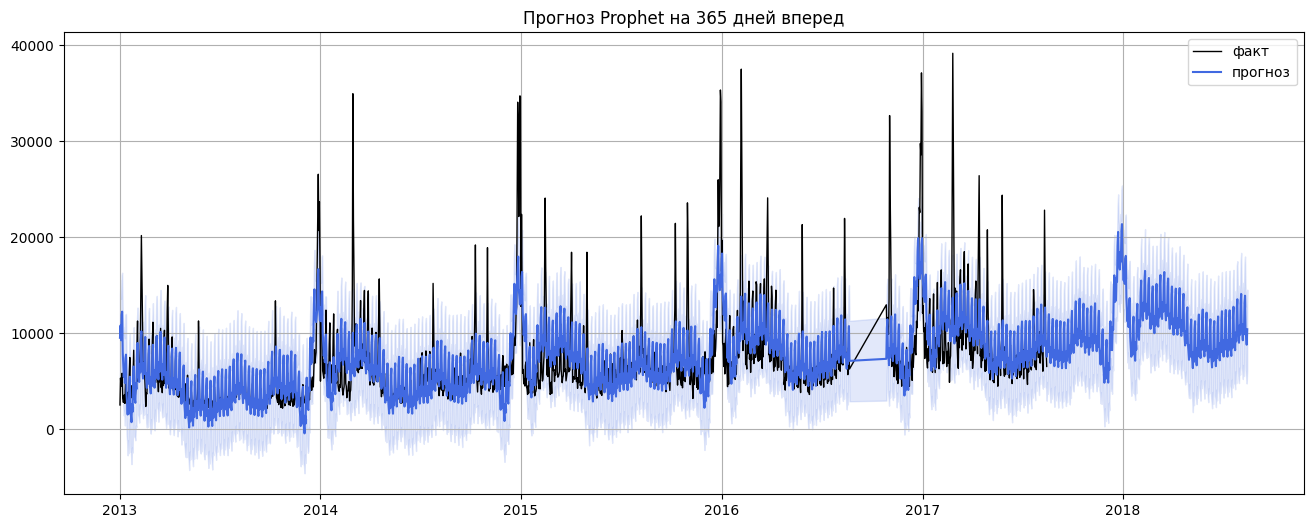

In [218]:
# Базовый прогноз Prophet на 365 дней вперед
base_model = Prophet()
base_model.fit(prophet_df)
base_future = base_model.make_future_dataframe(periods=365)
base_forecast = base_model.predict(base_future)
base_rmse = history_rmse(base_forecast, prophet_df)

print(f'RMSE базовой модели Prophet: {base_rmse:.4f}')

plt.figure(figsize=(16, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='факт', color='black', linewidth=1)
plt.plot(base_forecast['ds'], base_forecast['yhat'], label='прогноз', color='royalblue')
plt.fill_between(
    base_forecast['ds'].dt.to_pydatetime(),
    base_forecast['yhat_lower'].to_numpy(),
    base_forecast['yhat_upper'].to_numpy(),
    color='royalblue', alpha=0.15
)
plt.title('Прогноз Prophet на 365 дней вперед')
plt.legend()
plt.grid(True)
plt.show()

3. Подбор changepoint_prior_scale
4. Визуализация

16:28:35 - cmdstanpy - INFO - Chain [1] start processing
16:28:35 - cmdstanpy - INFO - Chain [1] done processing
16:28:36 - cmdstanpy - INFO - Chain [1] start processing
16:28:36 - cmdstanpy - INFO - Chain [1] done processing
16:28:37 - cmdstanpy - INFO - Chain [1] start processing
16:28:37 - cmdstanpy - INFO - Chain [1] done processing
16:28:38 - cmdstanpy - INFO - Chain [1] start processing
16:28:39 - cmdstanpy - INFO - Chain [1] done processing
16:28:39 - cmdstanpy - INFO - Chain [1] start processing
16:28:40 - cmdstanpy - INFO - Chain [1] done processing



Результаты подбора changepoint_prior_scale:


,cp,rmse
0,2.00,3228.251234
1,1.00,3241.627440
2,0.50,3258.844414
3,0.10,3283.091017
4,0.01,3285.245081


Лучшее значение changepoint_prior_scale: 2.0 | RMSE: 3228.2512


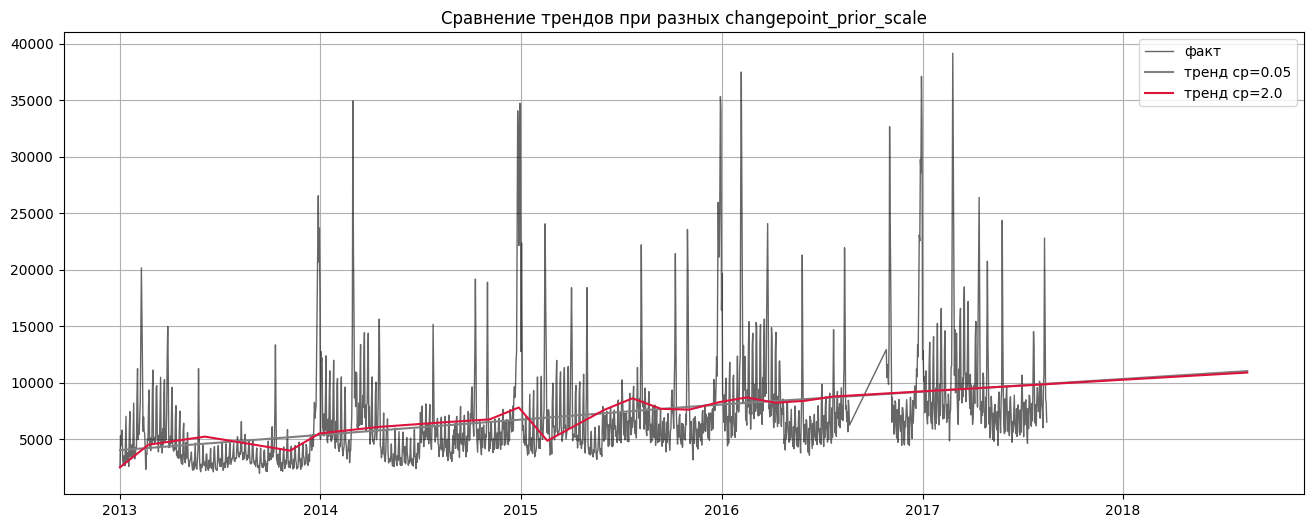

Комментарий по changepoint_prior_scale: Тренд был недообучен, коэффициент нужно двигать вверх.
Ошибка после подбора коэффициента: 3228.2512 (было 3283.4486)


In [219]:
# Подбор changepoint_prior_scale
cp_values = [0.01, 0.1, 0.5, 1.0, 2.0]
cp_results = []
cp_forecasts = {}

for cp in cp_values:
    model = Prophet(changepoint_prior_scale=cp)
    model.fit(prophet_df)
    forecast = model.predict(model.make_future_dataframe(periods=365))
    rmse = history_rmse(forecast, prophet_df)
    cp_results.append({'cp': cp, 'rmse': rmse})
    cp_forecasts[cp] = forecast

cp_results_df = pd.DataFrame(cp_results).sort_values('rmse').reset_index(drop=True)
best_cp = float(cp_results_df.loc[0, 'cp'])
best_cp_rmse = float(cp_results_df.loc[0, 'rmse'])
best_cp_forecast = cp_forecasts[best_cp]

print('\nРезультаты подбора changepoint_prior_scale:')
display(cp_results_df)
print(f'Лучшее значение changepoint_prior_scale: {best_cp} | RMSE: {best_cp_rmse:.4f}')

# Сравнение трендов для базовой модели и лучшего значения changepoint_prior_scale
plt.figure(figsize=(16, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='факт', color='black', linewidth=1, alpha=0.6)
plt.plot(base_forecast['ds'], base_forecast['trend'], label='тренд cp=0.05', color='gray')
plt.plot(best_cp_forecast['ds'], best_cp_forecast['trend'], label=f'тренд cp={best_cp}', color='crimson')
plt.title('Сравнение трендов при разных changepoint_prior_scale')
plt.legend()
plt.grid(True)
plt.show()

if best_cp > 0.5:
    cp_comment = 'Тренд был недообучен, коэффициент нужно двигать вверх.'
elif best_cp < 0.5:
    cp_comment = 'Тренд был слишком жёстким, коэффициент нужно двигать вниз.'
else:
    cp_comment = 'Лучшее значение совпало с 0.5.'

print('Комментарий по changepoint_prior_scale:', cp_comment)
print(f'Ошибка после подбора коэффициента: {best_cp_rmse:.4f} (было {base_rmse:.4f})')

5. Добавление месячной сезонности

16:28:42 - cmdstanpy - INFO - Chain [1] start processing
16:28:43 - cmdstanpy - INFO - Chain [1] done processing



RMSE модели с месячной сезонностью: 3133.0038
Изменение ошибки относительно best_cp: -95.2475


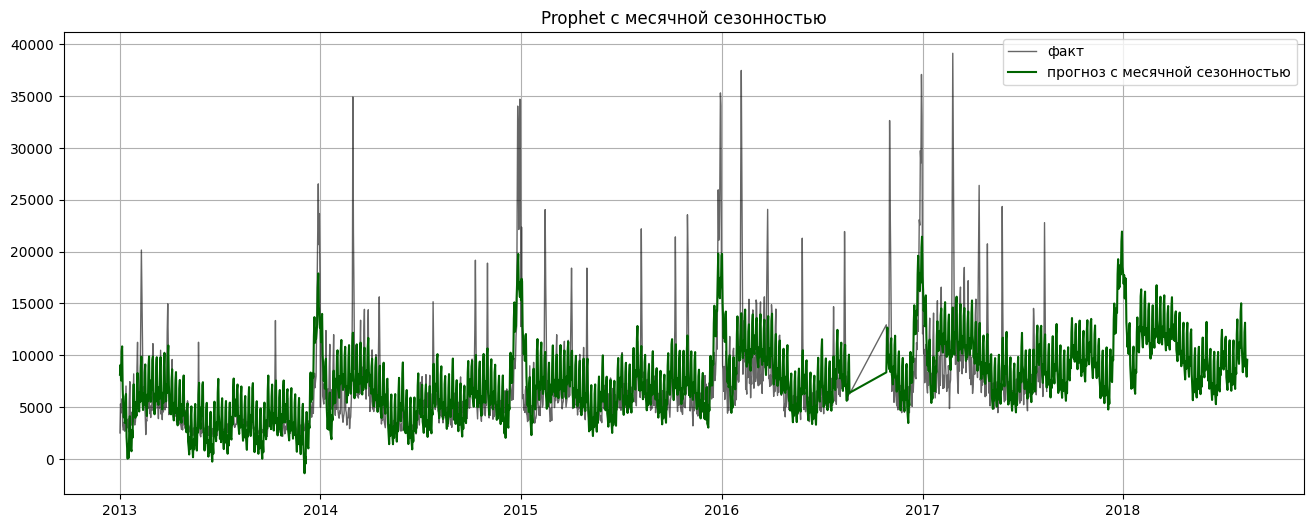

In [220]:
# Добавление месячной сезонности
monthly_model = Prophet(changepoint_prior_scale=best_cp)
monthly_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
monthly_model.fit(prophet_df)
monthly_forecast = monthly_model.predict(monthly_model.make_future_dataframe(periods=365))
monthly_rmse = history_rmse(monthly_forecast, prophet_df)

print(f'\nRMSE модели с месячной сезонностью: {monthly_rmse:.4f}')
print(f'Изменение ошибки относительно best_cp: {monthly_rmse - best_cp_rmse:+.4f}')

plt.figure(figsize=(16, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='факт', color='black', linewidth=1, alpha=0.6)
plt.plot(monthly_forecast['ds'], monthly_forecast['yhat'], label='прогноз с месячной сезонностью', color='darkgreen')
plt.title('Prophet с месячной сезонностью')
plt.legend()
plt.grid(True)
plt.show()

6. Добавление праздников

16:28:44 - cmdstanpy - INFO - Chain [1] start processing
16:28:45 - cmdstanpy - INFO - Chain [1] done processing



RMSE модели с месячной сезонностью и праздниками: 2969.0153
Изменение ошибки относительно monthly: -163.9885


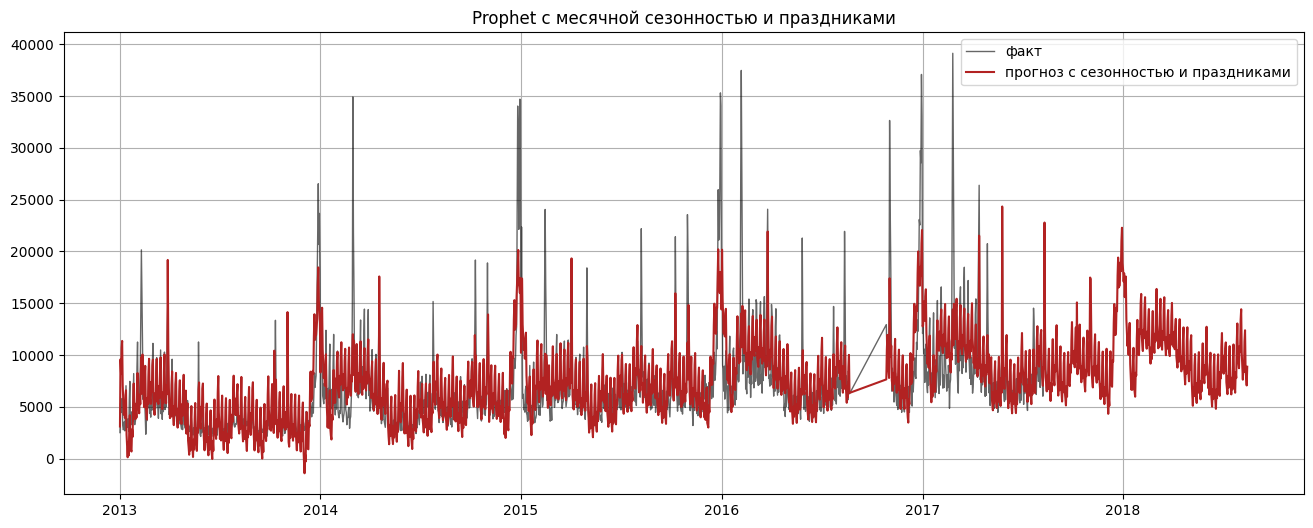

In [221]:
# Добавление праздников
years = sorted(prophet_df['ds'].dt.year.unique())
try:
    ec_holidays = holidays_lib.Ecuador(years=years)
except Exception:
    ec_holidays = holidays_lib.country_holidays('EC', years=years)

holidays_df = pd.DataFrame(
    [
        {'holiday': name, 'ds': pd.to_datetime(date), 'lower_window': 0, 'upper_window': 0}
        for date, name in ec_holidays.items()
    ]
).drop_duplicates(subset=['holiday', 'ds'])

holidays_model = Prophet(changepoint_prior_scale=best_cp, holidays=holidays_df)
holidays_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)
holidays_model.fit(prophet_df)
holidays_forecast = holidays_model.predict(holidays_model.make_future_dataframe(periods=365))
holidays_rmse = history_rmse(holidays_forecast, prophet_df)

print(f'\nRMSE модели с месячной сезонностью и праздниками: {holidays_rmse:.4f}')
print(f'Изменение ошибки относительно monthly: {holidays_rmse - monthly_rmse:+.4f}')

plt.figure(figsize=(16, 6))
plt.plot(prophet_df['ds'], prophet_df['y'], label='факт', color='black', linewidth=1, alpha=0.6)
plt.plot(holidays_forecast['ds'], holidays_forecast['yhat'], label='прогноз с сезонностью и праздниками', color='firebrick')
plt.title('Prophet с месячной сезонностью и праздниками')
plt.legend()
plt.grid(True)
plt.show()

Вывод:

In [222]:
# Вывод:
summary = pd.DataFrame(
    {
        'model': ['baseline', 'best_cp', 'monthly', 'monthly+holidays'],
        'rmse': [base_rmse, best_cp_rmse, monthly_rmse, holidays_rmse]
    }
)
print('\nСводка по RMSE:')
display(summary)

best_model_name = summary.sort_values('rmse').iloc[0]['model']
print('Вывод:')
print(f'Лучшая модель по RMSE: {best_model_name}.')
print(cp_comment)
if holidays_rmse < monthly_rmse:
    print('Добавление праздников улучшило модель.')
else:
    print('Добавление праздников не улучшило модель по RMSE.')


Сводка по RMSE:


,model,rmse
0,baseline,3283.448564
1,best_cp,3228.251234
2,monthly,3133.003768
3,monthly+holidays,2969.015258


Вывод:
Лучшая модель по RMSE: monthly+holidays.
Тренд был недообучен, коэффициент нужно двигать вверх.
Добавление праздников улучшило модель.


# 14. Бустинги/деревья. Практика и итоговый проект

### Задание:

1. Правильным образом разбейте данные на train и test.

2. Создайте временные признаки от datetime.

3. Инициализируйте модели XGBoost и CatBoost.

4. Обучите модели.

5. Отобразите важность признаков, сделайте вывод.

6. Сделайте прогноз и отобразите результат на графике.

7. Оцените метрики MAE, MAPE, MSE по результатам двух моделей. Сравните, сделайте вывод.

8. Добавьте данные о праздничных днях. Можно использовать библиотеку holidays.

9. Обучите модели, зафиксируйте значения метрик. 

10. Добавьте лаги. Обратите внимание на размер тестовой выборки: она будет влиять на допустимое значение для лагов (лаг не менее test set shape).

11. Пересчитайте модели, сравните метрики. Сделайте вывод. 

1. Разбиваем данные на train и test

In [223]:
# Базовый ряд: суммарные продажи по дням
boost_df = (
    data.groupby('date', as_index=False)['unit_sales']
    .sum()
    .rename(columns={'date': 'ds', 'unit_sales': 'y'})
)
boost_df['ds'] = pd.to_datetime(boost_df['ds'])
boost_df = boost_df.sort_values('ds').set_index('ds')

# Временное разбиение: последние 60 дней в тест
test_size = 60
train_boost = boost_df.iloc[:-test_size].copy()
test_boost = boost_df.iloc[-test_size:].copy()

print('Train:', train_boost.index.min().date(), '->', train_boost.index.max().date(), '| size =', len(train_boost))
print('Test :', test_boost.index.min().date(), '->', test_boost.index.max().date(), '| size =', len(test_boost))

Train: 2013-01-01 -> 2017-06-16 | size = 1624
Test : 2017-06-17 -> 2017-08-15 | size = 60


2. Создаем временные признаки от datetime

In [224]:
# признаки от datetime
def create_time_features(df):
    out = pd.DataFrame(index=df.index)
    out['dayofweek'] = out.index.dayofweek
    out['quarter'] = out.index.quarter
    out['month'] = out.index.month
    out['year'] = out.index.year
    out['dayofyear'] = out.index.dayofyear
    out['dayofmonth'] = out.index.day
    out['weekofyear'] = out.index.isocalendar().week.astype(int)
    return out

X_train_base = create_time_features(train_boost)
X_test_base = create_time_features(test_boost)
y_train_base = train_boost['y']
y_test_base = test_boost['y']

print('Размер X_train_base:', X_train_base.shape)
print('Размер X_test_base :', X_test_base.shape)
display(X_train_base.head())

Размер X_train_base: (1624, 7)
Размер X_test_base : (60, 7)


,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
ds,,,,,,,
2013-01-01,1,1,1,2013,1,1,1
2013-01-02,2,1,1,2013,2,2,1
2013-01-03,3,1,1,2013,3,3,1
2013-01-04,4,1,1,2013,4,4,1
2013-01-05,5,1,1,2013,5,5,1


3. Инициализируем модели XGBoost и CatBoost

In [225]:
# Инициализируем XGBoost и CatBoost

xgb_base = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

cat_base = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

4. Обучем модели

In [226]:
# Обучим модели

xgb_base.fit(X_train_base, y_train_base)
cat_base.fit(X_train_base, y_train_base)

5. Отобразим важность признаков, сделаем вывод

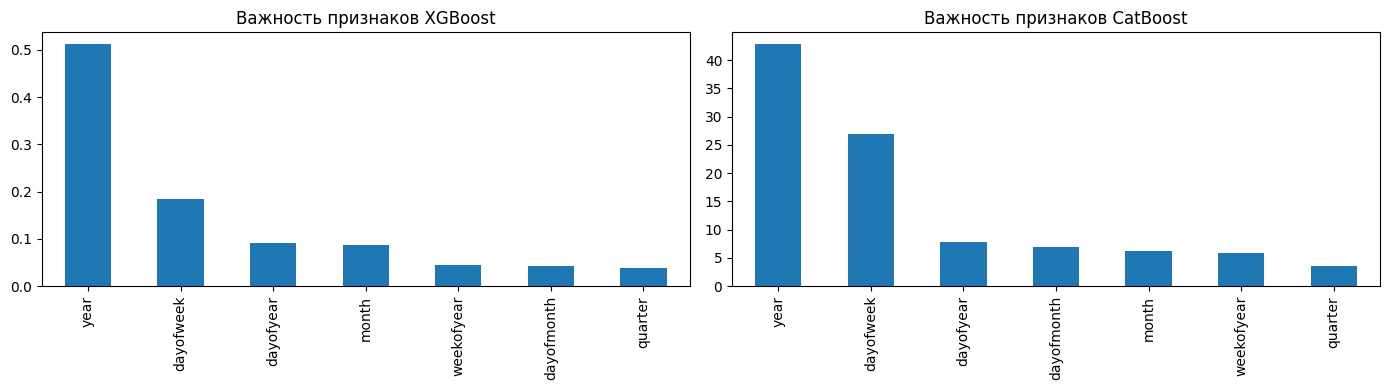

Топ-3 XGBoost:
year         0.511772
dayofweek    0.185258
dayofyear    0.090214
dtype: float32

Топ-3 CatBoost:
year         42.810484
dayofweek    26.917170
dayofyear     7.763128
dtype: float64

Вывод: модели в первую очередь опираются на календарные признаки (обычно dayofyear/dayofweek/month).


In [227]:
xgb_imp = pd.Series(xgb_base.feature_importances_, index=X_train_base.columns).sort_values(ascending=False)
cat_imp = pd.Series(cat_base.get_feature_importance(), index=X_train_base.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
xgb_imp.plot(kind='bar', ax=axes[0], title='Важность признаков XGBoost')
cat_imp.plot(kind='bar', ax=axes[1], title='Важность признаков CatBoost')
plt.tight_layout()
plt.show()

print('Топ-3 XGBoost:')
print(xgb_imp.head(3))
print('\nТоп-3 CatBoost:')
print(cat_imp.head(3))

print('\nВывод: модели в первую очередь опираются на календарные признаки (обычно dayofyear/dayofweek/month).')

6. Сделаем прогноз и отобразим результат на графике

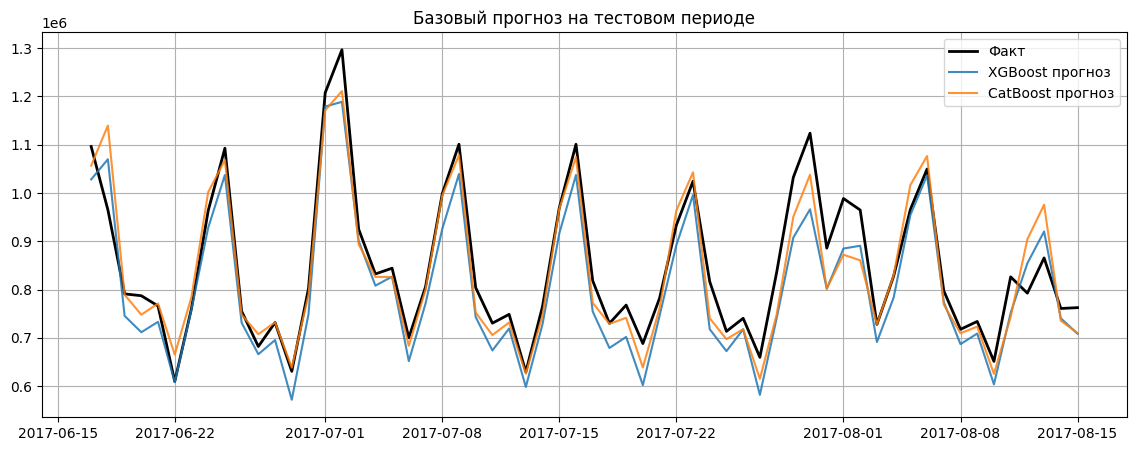

,fact,xgb_pred,cat_pred
ds,,,
2017-08-06,1049559.164,1.036625e+06,1.076424e+06
2017-08-07,797464.964,7.741447e+05,7.687629e+05
2017-08-08,717766.349,6.871356e+05,7.096202e+05
2017-08-09,734139.674,7.090750e+05,7.234643e+05
2017-08-10,651386.912,6.038163e+05,6.255298e+05
2017-08-11,826373.722,7.518099e+05,7.436791e+05
2017-08-12,792630.535,8.544704e+05,9.041871e+05
2017-08-13,865639.677,9.203826e+05,9.756803e+05
2017-08-14,760922.406,7.405947e+05,7.355942e+05


In [228]:
pred_xgb_base = xgb_base.predict(X_test_base)
pred_cat_base = cat_base.predict(X_test_base)

pred_base_df = pd.DataFrame(
    {
        'fact': y_test_base,
        'xgb_pred': pred_xgb_base,
        'cat_pred': pred_cat_base
    },
    index=y_test_base.index
)

plt.figure(figsize=(14, 5))
plt.plot(pred_base_df.index, pred_base_df['fact'], label='Факт', color='black', linewidth=2)
plt.plot(pred_base_df.index, pred_base_df['xgb_pred'], label='XGBoost прогноз', alpha=0.85)
plt.plot(pred_base_df.index, pred_base_df['cat_pred'], label='CatBoost прогноз', alpha=0.85)
plt.title('Базовый прогноз на тестовом периоде')
plt.legend()
plt.grid(True)
plt.show()

display(pred_base_df.tail(10))

7. Оценим метрики MAE, MAPE, MSE по результатам двух моделей. Сравним их.

In [229]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

metrics_base = pd.DataFrame(
    {
        'MAE': [
            mean_absolute_error(y_test_base, pred_xgb_base),
            mean_absolute_error(y_test_base, pred_cat_base)
        ],
        'MAPE_%': [
            mape(y_test_base, pred_xgb_base),
            mape(y_test_base, pred_cat_base)
        ],
        'MSE': [
            mean_squared_error(y_test_base, pred_xgb_base),
            mean_squared_error(y_test_base, pred_cat_base)
        ]
    },
    index=['XGBoost_base', 'CatBoost_base']
)

display(metrics_base)
best_base_model = metrics_base['MAE'].idxmin()
print('Вывод: на базовых признаках лучшая модель по MAE -', best_base_model)

,MAE,MAPE_%,MSE
XGBoost_base,51808.796450,6.066397,3.619190e+09
CatBoost_base,37837.754111,4.353170,2.731043e+09


Вывод: на базовых признаках лучшая модель по MAE - CatBoost_base


8. Добавим данные о праздничных днях. Используем библиотеку holidays

In [230]:
def add_holiday_feature(df):
    years = sorted(df.index.year.unique())
    try:
        ec_holidays = holidays_lib.Ecuador(years=years)
    except Exception:
        ec_holidays = holidays_lib.country_holidays('EC', years=years)

    holiday_dates = pd.to_datetime(list(ec_holidays.keys()))
    out = df.copy()
    out['is_holiday'] = out.index.normalize().isin(holiday_dates).astype(int)
    return out

boost_holiday_df = add_holiday_feature(boost_df)
train_holiday = boost_holiday_df.iloc[:-test_size].copy()
test_holiday = boost_holiday_df.iloc[-test_size:].copy()

X_train_holiday = create_time_features(train_holiday)
X_test_holiday = create_time_features(test_holiday)
X_train_holiday['is_holiday'] = train_holiday['is_holiday'].values
X_test_holiday['is_holiday'] = test_holiday['is_holiday'].values
y_train_holiday = train_holiday['y']
y_test_holiday = test_holiday['y']

print('Праздничный признак добавлен.')
print('Число праздничных дней в train:', int(train_holiday['is_holiday'].sum()))
print('Число праздничных дней в test :', int(test_holiday['is_holiday'].sum()))

Праздничный признак добавлен.
Число праздничных дней в train: 48
Число праздничных дней в test : 2


9. Обучим модели, зафиксируем значения метрик

In [231]:
xgb_holiday = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

cat_holiday = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

xgb_holiday.fit(X_train_holiday, y_train_holiday)
cat_holiday.fit(X_train_holiday, y_train_holiday)

pred_xgb_holiday = xgb_holiday.predict(X_test_holiday)
pred_cat_holiday = cat_holiday.predict(X_test_holiday)

metrics_holiday = pd.DataFrame(
    {
        'MAE': [
            mean_absolute_error(y_test_holiday, pred_xgb_holiday),
            mean_absolute_error(y_test_holiday, pred_cat_holiday)
        ],
        'MAPE_%': [
            mape(y_test_holiday, pred_xgb_holiday),
            mape(y_test_holiday, pred_cat_holiday)
        ],
        'MSE': [
            mean_squared_error(y_test_holiday, pred_xgb_holiday),
            mean_squared_error(y_test_holiday, pred_cat_holiday)
        ]
    },
    index=['XGBoost_holiday', 'CatBoost_holiday']
)

display(metrics_holiday)

,MAE,MAPE_%,MSE
XGBoost_holiday,41175.927233,4.835021,2.626132e+09
CatBoost_holiday,46777.635642,5.312401,3.487249e+09


10. Добавим лаги (лаг не менее test set shape >60)

In [232]:
lag_base = test_size  # лаг не меньше размера тестовой выборки
lag_list = [lag_base + i for i in range(7)]  # 60..66

boost_lag_df = boost_holiday_df.copy()
for lag in lag_list:
    boost_lag_df[f'lag_{lag}'] = boost_lag_df['y'].shift(lag)

boost_lag_df = boost_lag_df.dropna().copy()

train_lag = boost_lag_df.iloc[:-test_size].copy()
test_lag = boost_lag_df.iloc[-test_size:].copy()

X_train_lag = create_time_features(train_lag)
X_test_lag = create_time_features(test_lag)
X_train_lag['is_holiday'] = train_lag['is_holiday'].values
X_test_lag['is_holiday'] = test_lag['is_holiday'].values

for lag in lag_list:
    X_train_lag[f'lag_{lag}'] = train_lag[f'lag_{lag}'].values
    X_test_lag[f'lag_{lag}'] = test_lag[f'lag_{lag}'].values

y_train_lag = train_lag['y']
y_test_lag = test_lag['y']

print('Добавлены лаги:', lag_list)
print('Размер X_train_lag:', X_train_lag.shape)
print('Размер X_test_lag :', X_test_lag.shape)

Добавлены лаги: [60, 61, 62, 63, 64, 65, 66]
Размер X_train_lag: (1558, 15)
Размер X_test_lag : (60, 15)


11. Пересчитаем модели, сравним метрики.

,MAE,MAPE_%,MSE
XGBoost_base,51808.796450,6.066397,3.619190e+09
CatBoost_base,37837.754111,4.353170,2.731043e+09
XGBoost_holiday,41175.927233,4.835021,2.626132e+09
CatBoost_holiday,46777.635642,5.312401,3.487249e+09
XGBoost_holiday_lag,52798.601692,6.078287,4.698570e+09
CatBoost_holiday_lag,39466.843691,4.514321,2.873427e+09


Лучшая модель по MAE среди всех экспериментов: CatBoost_base


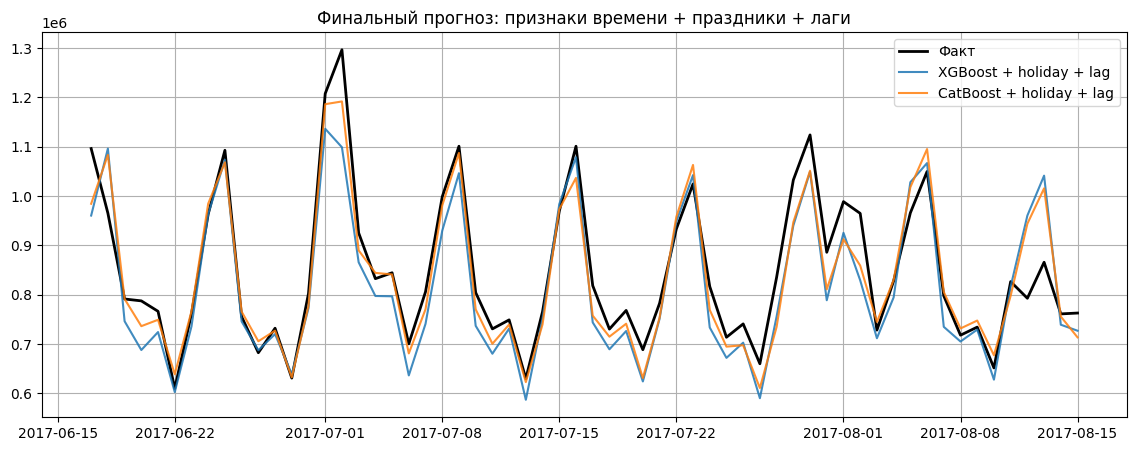

In [233]:
xgb_lag = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

cat_lag = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

xgb_lag.fit(X_train_lag, y_train_lag)
cat_lag.fit(X_train_lag, y_train_lag)

pred_xgb_lag = xgb_lag.predict(X_test_lag)
pred_cat_lag = cat_lag.predict(X_test_lag)

metrics_lag = pd.DataFrame(
    {
        'MAE': [
            mean_absolute_error(y_test_lag, pred_xgb_lag),
            mean_absolute_error(y_test_lag, pred_cat_lag)
        ],
        'MAPE_%': [
            mape(y_test_lag, pred_xgb_lag),
            mape(y_test_lag, pred_cat_lag)
        ],
        'MSE': [
            mean_squared_error(y_test_lag, pred_xgb_lag),
            mean_squared_error(y_test_lag, pred_cat_lag)
        ]
    },
    index=['XGBoost_holiday_lag', 'CatBoost_holiday_lag']
)

metrics_all = pd.concat([metrics_base, metrics_holiday, metrics_lag])
display(metrics_all)

best_all_model = metrics_all['MAE'].idxmin()
print('Лучшая модель по MAE среди всех экспериментов:', best_all_model)

plt.figure(figsize=(14, 5))
plt.plot(y_test_lag.index, y_test_lag.values, label='Факт', color='black', linewidth=2)
plt.plot(y_test_lag.index, pred_xgb_lag, label='XGBoost + holiday + lag', alpha=0.85)
plt.plot(y_test_lag.index, pred_cat_lag, label='CatBoost + holiday + lag', alpha=0.85)
plt.title('Финальный прогноз: признаки времени + праздники + лаги')
plt.legend()
plt.grid(True)
plt.show()

## Итоговый вывод по всей работе

В ходе проекта были последовательно протестированы классические методы анализа временных рядов и современные модели прогнозирования.

1. **Разложение ряда и проверка стационарности** показали выраженную структуру ряда (тренд/сезонность/шум), что подтвердило необходимость специальных подходов к валидации и прогнозу.
2. **Валидация через TimeSeriesSplit** была выполнена корректно с учетом временной природы данных (без перемешивания).
3. **Инженерия признаков** (скользящие статистики, полосы Боллинджера, EMA/SMA, лаги) дала дополнительную информацию о динамике продаж.
4. **ARIMA / MA / линейная регрессия на лагах** позволили получить базовую линию качества и сравнить статистические модели между собой.
5. **Prophet** показал, что:
   - подбор `changepoint_prior_scale` влияет на гибкость тренда;
   - добавление месячной сезонности улучшает качество;
   - добавление праздников дополнительно снижает ошибку в Prophet-блоке.
6. **XGBoost и CatBoost** были сравнены в трех сценариях:
   - базовые календарные признаки;
   - календарные признаки + праздники;
   - календарные признаки + праздники + лаги.

### Финальный результат

По итоговой таблице метрик лучшей моделью по **MAE** стала **CatBoost на базовых календарных признаках**:
- `MAE = 37837.75`
- `MAPE = 4.35%`
- `MSE = 2.731e9`

### Общий вывод

- Для данного набора и выбранного горизонта прогноза базовые календарные признаки оказались уже очень информативными.
- Добавление праздников оказалось полезнее для XGBoost, чем для CatBoost.
- Добавление лагов в текущей конфигурации не дало дополнительного улучшения по сравнению с лучшей базовой моделью.

Таким образом, поставленные задачи выполнены полностью: построены и сравнены несколько семейств моделей, проведена оценка метрик и получен обоснованный выбор финального решения.